In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

In [2]:
# verificar gpu
print("dispositivos disponibles:")
print(tf.config.list_physical_devices())

print("\nGPU: ")
print(tf.config.list_physical_devices('GPU'))


dispositivos disponibles:
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

GPU: 
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [12]:
#from tensorflow import keras
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

print("X_Train:", X_train.shape)
print("y_Train:", y_train.shape)
print("X_Test:", X_test.shape)
print("y_Test:", y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_Train: (60000, 28, 28)
y_Train: (60000,)
X_Test: (10000, 28, 28)
y_Test: (10000,)


In [13]:
from tensorflow.keras import layers
from sklearn.metrics import(
    confusion_matrix,
    classification_report,
)

In [14]:
# nombre de clases
class_names=[
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

for i, name in enumerate(class_names):
    print(f"{i}: {name}")

0: T-shirt/top
1: Trouser
2: Pullover
3: Dress
4: Coat
5: Sandal
6: Shirt
7: Sneaker
8: Bag
9: Ankle boot


In [15]:
# exploracion con numpy
print("Tipo de X_Train", type(X_train))
print("Tipo de y_Train", type(y_train))

print("\nDimensiones de X_train", X_train.ndim)
print("Forma de X_train", X_train.shape)

print("\nValor minimo", X_train.min())
print("Valor maximo", X_train.max())


Tipo de X_Train <class 'numpy.ndarray'>
Tipo de y_Train <class 'numpy.ndarray'>

Dimensiones de X_train 3
Forma de X_train (60000, 28, 28)

Valor minimo 0
Valor maximo 255


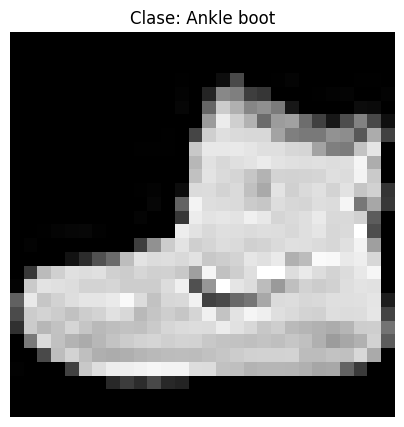

In [16]:
# visualizar imagen
plt.figure(figsize=(5,5))
plt.imshow(X_train[0], cmap="gray")
plt.title(
    f"Clase: {class_names[y_train[0]]}"

)
plt.axis("off")
plt.show()


In [17]:
print(X_train[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1   1   0 200 232 23

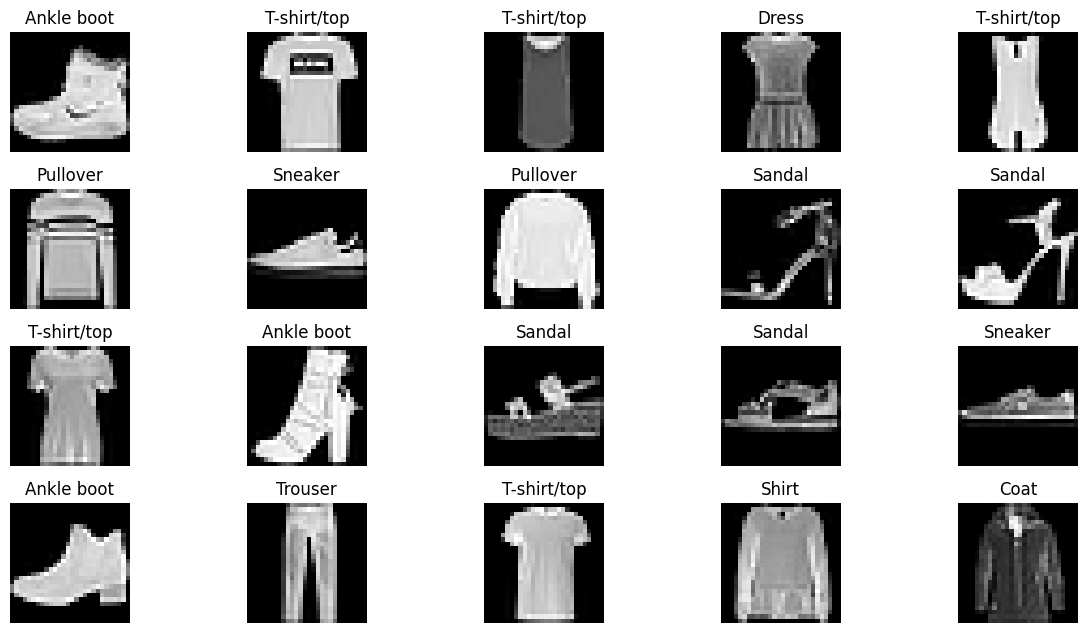

In [18]:
# galeria de imagenes

plt.figure(figsize=(12,8))
for i in range(20):
    plt.subplot(5,5,i+1)
    plt.imshow(
        X_train[i],
        cmap="gray"
    )
    plt.title(
        class_names[y_train[i]]
    )

    plt.axis("off")
plt.tight_layout()
plt.show()

In [19]:
# vamos a etiquetar

df_labels = pd.DataFrame({
    "label": y_train,

})
df_labels["class_name"] = df_labels["label"].map(
    lambda x: class_names[x] # def
)
df_labels.head()

,label,class_name
0,9,Ankle boot
1,0,T-shirt/top
2,0,T-shirt/top
3,3,Dress
4,0,T-shirt/top


In [21]:
df_labels.head(15)

,label,class_name
0,9,Ankle boot
1,0,T-shirt/top
2,0,T-shirt/top
3,3,Dress
4,0,T-shirt/top
5,2,Pullover
6,7,Sneaker
7,2,Pullover
8,5,Sandal
9,5,Sandal


In [22]:
df_labels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   label       60000 non-null  uint8 
 1   class_name  60000 non-null  object
dtypes: object(1), uint8(1)
memory usage: 527.5+ KB


In [23]:
from sklearn.utils.multiclass import class_distribution
# distribucion de clases
class_distribution = (
    df_labels["class_name"]
    .value_counts()
    .sort_index()
)

print(class_distribution)



class_name
Ankle boot     6000
Bag            6000
Coat           6000
Dress          6000
Pullover       6000
Sandal         6000
Shirt          6000
Sneaker        6000
T-shirt/top    6000
Trouser        6000
Name: count, dtype: int64


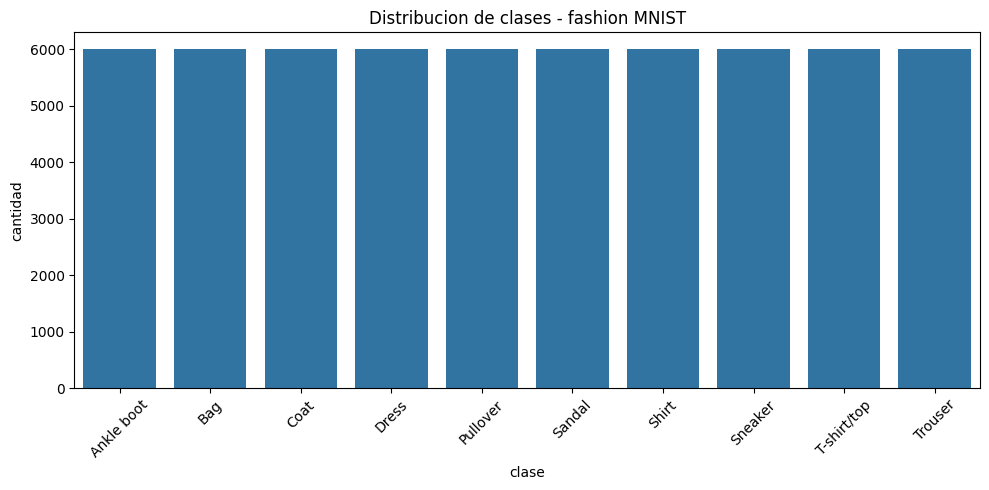

In [24]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=df_labels,
    x="class_name",
    order=class_distribution.index
)

plt.title("Distribucion de clases - fashion MNIST")
plt.xlabel("clase")
plt.ylabel("cantidad")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
# normalizamos los datos
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0
print("Minimo: ", X_train.min())
print("Maximo: ", X_train.min())

Minimo:  0.0
Maximo:  0.0


In [28]:
print(X_train[0])

[[0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
  0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
  0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
  0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
  0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
  0.0000000e+00 0.0000000e+00 0.0000000e+00]
 [0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
  0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
  0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
  0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
  0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
  0.0000000e+00 0.0000000e+00 0.0000000e+00]
 [0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
  0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
  0.0000000e+00 0.0000000e+00 0.0000000e+00 0.

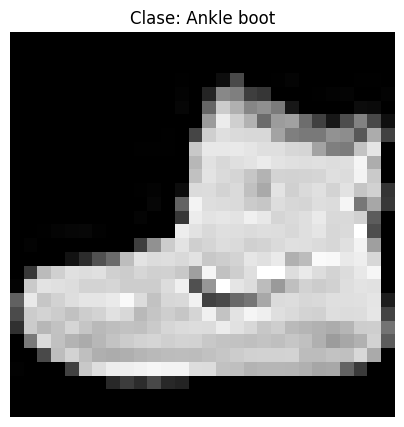

In [29]:
# visualizar imagen
plt.figure(figsize=(5,5))
plt.imshow(X_train[0], cmap="gray")
plt.title(
    f"Clase: {class_names[y_train[0]]}"

)
plt.axis("off")
plt.show()

In [30]:
# flatten ( aplanar un conjunto de imagenes)
X_train_flat = X_train.reshape(
    X_train.shape[0],
    784
)
X_test_flat = X_test.reshape(
    X_test.shape[0],
    784
)

print("Antes: ")
print(X_train.shape)

print("\nDespues: ")
print(X_train_flat.shape)



Antes: 
(60000, 28, 28)

Despues: 
(60000, 784)


In [31]:
# comparacion
print("Imagen original", X_train[0].shape)
print("Imagen aplanada(flatten)", X_train_flat[0].shape)

Imagen original (28, 28)
Imagen aplanada(flatten) (784,)


In [32]:
# crear el modelo keras
model  = keras.Sequential(
    [
        layers.Input(shape=(784,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(10,activation="softmax")
    ]
)

In [33]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# compilar modelo
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [35]:
#entrenar modelo
history = model.fit(
    X_train_flat,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,

)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6559 - loss: 0.9760 - val_accuracy: 0.7577 - val_loss: 0.6500
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7774 - loss: 0.6061 - val_accuracy: 0.7909 - val_loss: 0.5600
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8054 - loss: 0.5371 - val_accuracy: 0.8096 - val_loss: 0.5228
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8223 - loss: 0.4961 - val_accuracy: 0.8269 - val_loss: 0.4823
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8322 - loss: 0.4695 - val_accuracy: 0.8327 - val_loss: 0.4701
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8403 - loss: 0.4484 - val_accuracy: 0.8369 - val_loss: 0.4476
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8460 - loss: 0.4328 - val_accuracy: 0.8402 - val_loss: 0.4454
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8498 - loss: 0.4207 - 

In [36]:
#historial de entrenamiento
history_df = pd.DataFrame(history.history)
history_df.head()

,accuracy,loss,val_accuracy,val_loss
0,0.655875,0.976011,0.757667,0.649976
1,0.777417,0.606114,0.790917,0.560049
2,0.805417,0.537140,0.809583,0.522788
3,0.822292,0.496134,0.826917,0.482338
4,0.832250,0.469462,0.832667,0.470121


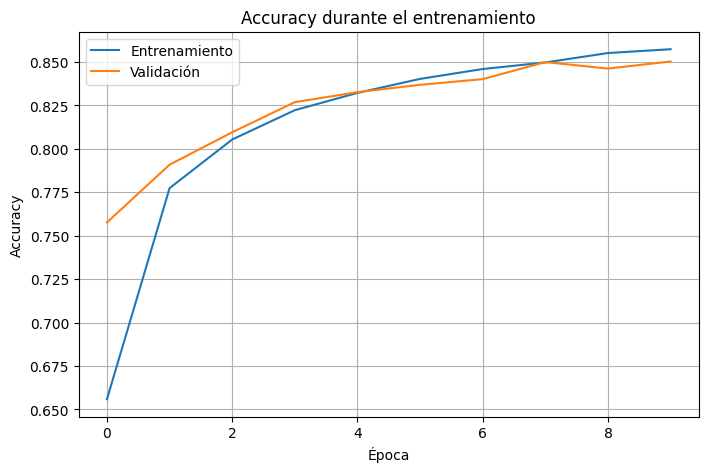

In [37]:
# ACCURACY





plt.figure(figsize=(8, 5))



plt.plot(

  history.history["accuracy"],

  label="Entrenamiento"

)



plt.plot(

  history.history["val_accuracy"],

  label="Validación"

)



plt.title(

  "Accuracy durante el entrenamiento"

)



plt.xlabel("Época")

plt.ylabel("Accuracy")



plt.legend()



plt.grid(True)



plt.show()

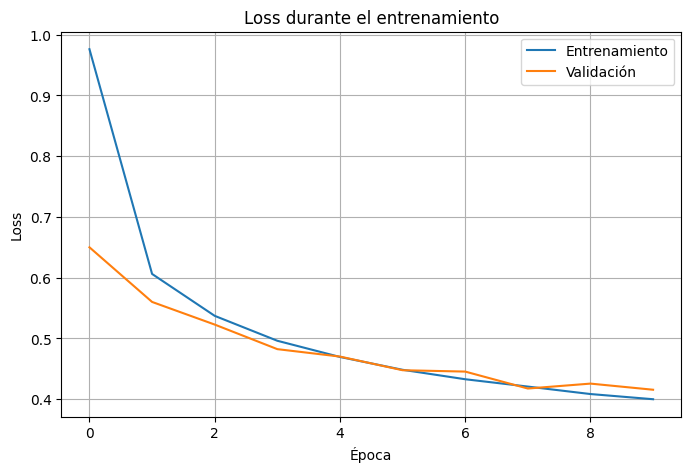

In [38]:
# LOSS





plt.figure(figsize=(8, 5))



plt.plot(

  history.history["loss"],

  label="Entrenamiento"

)



plt.plot(

  history.history["val_loss"],

  label="Validación"

)



plt.title(

  "Loss durante el entrenamiento"

)



plt.xlabel("Época")

plt.ylabel("Loss")



plt.legend()



plt.grid(True)



plt.show()

In [39]:
# evaluacion
test_loss, test_accuracy = model.evaluate(
    X_test_flat,
    y_test,
    verbose=1
)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8410 - loss: 0.4433
Test Loss: 0.44328558444976807
Test Accuracy: 0.8410000205039978
